In [2]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
import torch 
import copy

/opt/anaconda3/envs/solar-predict/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.utils import (
    print_post_norm_stats,
    print_raw_night_stats,
    train_val_test_split_indices
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    train_one_epoch,
    evaluate,
    evaluate_on_test,
    evaluate_csi_and_ghi,
)
from src.plot import(
    plot_full_images_from_loader,
)

from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)

ModuleNotFoundError: No module named 'utils'

In [1]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [4]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
)

print("Saved:", out)
print("Final shape:", shape)


Saved: Data/output/combined_hourly_with_elev_landmask_TEST.npz
Final shape: (7941, 12, 50, 50)


In [3]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/combined_hourly_with_elev_landmask_TEST.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (7941, 12, 50, 50)
y shape: (7941, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.054774634540081024 max 1.0


In [26]:
import numpy as np

def compute_means(arr):
    # arr: (T,H,W) or (T,1,H,W)
    if arr.ndim == 4:
        arr = arr[:, 0]
    return arr.mean(axis=(1,2))

def make_labels(c0, c1, csi,
                tw_cs_thr=76.0,      # W/m^2 : twilight if clear-sky GHI below this
                clear_thr=0.80,      # CSI mean threshold for "clear"
                cloudy_thr=0.35):    # CSI mean threshold for "cloudy"
    """
    Returns labels:
      0=twilight, 1=clear, 2=cloudy, 3=mixed
    """
    c0m  = compute_means(c0)
    c1m  = compute_means(c1)
    csim = compute_means(csi)

    labels = np.full(len(c1m), 3, dtype=np.int64)  # default mixed

    tw = c1m < tw_cs_thr
    labels[tw] = 0

    daytime = ~tw
    labels[daytime & (csim >= clear_thr)] = 1
    labels[daytime & (csim <= cloudy_thr)] = 2

    return labels, {"c0_mean": c0m, "c1_mean": c1m, "csi_mean": csim}


In [27]:
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_train_val_test_split(labels, train=0.7, val=0.15, test=0.15, seed=42):
    idx = np.arange(len(labels))

    idx_train, idx_tmp, y_train, y_tmp = train_test_split(
        idx, labels, test_size=(1-train), random_state=seed, stratify=labels
    )

    val_frac_of_tmp = val / (val + test)
    idx_val, idx_test, _, _ = train_test_split(
        idx_tmp, y_tmp, test_size=(1-val_frac_of_tmp),
        random_state=seed, stratify=y_tmp
    )
    return idx_train, idx_val, idx_test


In [29]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)

In [48]:
c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_train_val_test_split(labels, 0.8, 0.1, 0.1, seed=42)

In [49]:
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

channel_mean: [238.66437  247.30698  254.30418  276.60678  259.0976   278.6026
 277.43613  274.47504  263.09882   39.706436  34.05114    0.3652  ]
channel_std: [ 9.577975   11.47075    12.711327   19.808594   12.378416   20.610844
 20.99358    20.233007   16.079489    0.3124471  80.81088     0.48147944]

In [50]:
# 4) compute per-channel min max on TRAIN only
#    X_train: (T_train, C, H, W)
channel_min = np.nanmin(X_train, axis=(0, 2, 3))   # (C,)
channel_max = np.nanmax(X_train, axis=(0, 2, 3))   # (C,)

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

print("channel_min:", channel_min)
print("channel_max:", channel_max)

np.savez(
    "Data/static/minmax_strat_stats_day.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)


channel_min: [188.29    185.64    185.78    184.56999 209.95    185.2     183.79
 184.44    187.04     38.89      0.        0.     ]
channel_max: [258.32    268.34    272.69998 306.74    278.75    311.07    309.61
 302.5     281.1      40.57    804.1716    1.     ]


In [53]:
from torch.utils.data import DataLoader

train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)

batch_size = 32


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def gn(ch, groups=8):
    return nn.GroupNorm(num_groups=min(groups, ch), num_channels=ch)

class FiLM(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gamma = nn.Conv2d(ch, ch, 1)
        self.beta  = nn.Conv2d(ch, ch, 1)

    def forward(self, x, cond):
        g = torch.tanh(self.gamma(cond))
        b = self.beta(cond)
        return x * (1.0 + g) + b

class ResBlockGN(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.n1 = gn(ch)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.n2 = gn(ch)
        self.act = nn.GELU()

    def forward(self, x):
        h = self.act(self.n1(self.c1(x)))
        h = self.n2(self.c2(h))
        return self.act(x + h)

class TwinFiLMUNetTiny(nn.Module):
    """
    Input:  (B,12,H,W)  [0:9]=LW/IR, [9:12]=geo (elev+landmask)
    Output: (B,1,H,W)   CSI regression (linear). Add sigmoid outside if your CSI is [0,1].
    """
    def __init__(self, feature_size=48):
        super().__init__()

        # stems
        self.enc_atmos = nn.Sequential(
            nn.Conv2d(9, feature_size, 3, padding=1, bias=False),
            gn(feature_size),
            nn.GELU(),
            ResBlockGN(feature_size),
        )
        self.enc_geo = nn.Sequential(
            nn.Conv2d(3, feature_size, 3, padding=1, bias=False),
            gn(feature_size),
            nn.GELU(),
        )

        # conditioning
        self.film = FiLM(feature_size)

        # multi-scale (64->32->64)
        self.down = nn.Sequential(
            nn.Conv2d(feature_size, feature_size * 2, 3, stride=2, padding=1, bias=False),
            gn(feature_size * 2),
            nn.GELU(),
            ResBlockGN(feature_size * 2),
        )
        self.up = nn.Sequential(
            nn.Conv2d(feature_size * 2, feature_size, 3, padding=1, bias=False),
            gn(feature_size),
            nn.GELU(),
            ResBlockGN(feature_size),
        )

        # fuse skip + upsampled context
        self.fuse = nn.Sequential(
            nn.Conv2d(feature_size * 2, feature_size, 1, bias=False),
            gn(feature_size),
            nn.GELU(),
            ResBlockGN(feature_size),
        )

        # head
        self.head = nn.Sequential(
            nn.Conv2d(feature_size, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, 1),
        )

    def forward(self, x):
        atmos = self.enc_atmos(x[:, :9])
        geo   = self.enc_geo(x[:, 9:])

        fused = self.film(atmos, geo)

        low = self.down(fused)  # (B,2F,H/2,W/2)
        low = F.interpolate(low, scale_factor=2, mode="bilinear", align_corners=False)
        low = self.up(low)      # (B,F,H,W)

        fused = self.fuse(torch.cat([fused, low], dim=1))
        return self.head(fused)


In [55]:
import kornia

criterion_reg  = nn.SmoothL1Loss(beta=0.03)  # sharper than 0.05
criterion_ssim = kornia.losses.SSIMLoss(window_size=11, reduction="mean")

def grad_loss(pred, true):
    dx_p = pred[..., :, 1:] - pred[..., :, :-1]
    dy_p = pred[..., 1:, :] - pred[..., :-1, :]
    dx_t = true[..., :, 1:] - true[..., :, :-1]
    dy_t = true[..., 1:, :] - true[..., :-1, :]
    return (dx_p - dx_t).abs().mean() + (dy_p - dy_t).abs().mean()

def lap_loss(pred, true):
    k = pred.new_tensor([[0,1,0],[1,-4,1],[0,1,0]]).reshape(1,1,3,3)
    lp = torch.nn.functional.conv2d(pred, k, padding=1)
    lt = torch.nn.functional.conv2d(true, k, padding=1)
    return (lp - lt).abs().mean()

def combined_loss(y_pred, y_true, w_reg=0.7, w_ssim=0.1, w_grad=0.15, w_lap=0.05):
    return (
        w_reg * criterion_reg(y_pred, y_true)
        + w_ssim * criterion_ssim(y_pred, y_true)
        + w_grad * grad_loss(y_pred, y_true)
        + w_lap * lap_loss(y_pred, y_true)
    )


In [ ]:
ckpt = torch.load("Model_checkpoint/ckpt_last.pt", map_location=device)

model.load_state_dict(ckpt["model"])
optimizer.load_state_dict(ckpt["optimizer"])

start_epoch = ckpt["epoch"] + 1

if scheduler is not None and ckpt["scheduler"] is not None:
    scheduler.load_state_dict(ckpt["scheduler"])


In [84]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
model = TwinFiLMUNetTiny(feature_size=48).to(device)

# -----------------------------
# Optimizer + scheduler
# -----------------------------
total_epochs = 150
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-4,
    steps_per_epoch=len(train_loader),
    epochs=total_epochs,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=5.0,        # initial lr = max_lr/div_factor
    final_div_factor=50.0  # final lr = initial_lr/final_div_factor
)
# resume
ckpt = torch.load("Model_checkpoint/ckpt_last2.pt", map_location=device)

model.load_state_dict(ckpt["model"])
optimizer.load_state_dict(ckpt["optimizer"])

start_epoch = ckpt["epoch"] + 1

if scheduler is not None and ckpt["scheduler"] is not None:
    scheduler.load_state_dict(ckpt["scheduler"])

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(total_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, combined_loss, device, scheduler)
    val_loss   = evaluate(model, val_loader, combined_loss, device)
    print(f"Epoch {epoch+1:03d}/{total_epochs}: loss={train_loss:.6f} | val {val_loss:.4f} | lr {optimizer.param_groups[0]['lr']}")


Epoch 001/150: loss=0.061142 | val 0.0855 | lr 3.088826327365052e-06
Epoch 002/150: loss=0.061127 | val 0.0855 | lr 2.6147033507671724e-06
Epoch 003/150: loss=0.061115 | val 0.0855 | lr 2.2750853940889526e-06
Epoch 004/150: loss=0.061109 | val 0.0855 | lr 2.070156366445085e-06
Epoch 005/150: loss=0.061106 | val 0.0855 | lr 2.0000272405192647e-06


ValueError: Tried to step 29851 times. The specified number of total steps is 29850

In [72]:
b = next(iter(train_loader))
print(type(b))
if isinstance(b, (list, tuple)):
    print("len:", len(b), "types:", [type(x) for x in b])
elif isinstance(b, dict):
    print("keys:", b.keys())


<class 'list'>
len: 2 types: [<class 'torch.Tensor'>, <class 'torch.Tensor'>]


In [73]:
# usage
metrics = evaluate_on_test(model, test_loader, device)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

RMSE: 0.133899
rRMSE: 0.189436
R2: 0.806077
MBE: 0.008085
MAE: 0.086178
mean_true: 0.706828


In [ ]:
no twillight included sigmoid 
RMSE: 0.130254
rRMSE: 0.183818
R2: 0.819233
MBE: -0.001009
MAE: 0.083949
mean_true: 0.708604

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

In [74]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)

ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)


swin
{'CSI_RMSE': 0.1379673331975937,
 'CSI_rRMSE': 0.19519218802452087,
 'CSI_R2': 0.7941124439239502,
 'CSI_MBE': 0.01562388613820076,
 'CSI_MAE': 0.08873958885669708,
 'CSI_mean_true': 0.7068281769752502,
 'GHI_RMSE': 78.64848327636719,
 'GHI_rRMSE': 0.1939978450536728,
 'GHI_R2': 0.9189393520355225,
 'GHI_MBE': 13.343442916870117,
 'GHI_MAE': 46.85791015625,
 'GHI_mean_true': 405.4090576171875}

In [76]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


CSI_RMSE: 0.133899
CSI_rRMSE: 0.189436
CSI_R2: 0.806077
CSI_MBE: 0.008085
CSI_MAE: 0.086178
CSI_mean_true: 0.706828
GHI_RMSE: 76.838295
GHI_rRMSE: 0.189533
GHI_R2: 0.922628
GHI_MBE: 8.518705
GHI_MAE: 45.806358
GHI_mean_true: 405.409058


In [77]:
ckpt_path = "Model_checkpoint/ckpt_last2.pt"

torch.save({
    "epoch": epoch,                      # current epoch index (0-based)
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict() if scheduler is not None else None,
}, ckpt_path)


In [34]:
PATH = "Model_checkpoint/Swin+_elevation_no_twil.pth"
torch.save(model.state_dict(), PATH)

In [78]:
import torch
import torch.nn.functional as F

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

# 1) load checkpoint
ckpt = torch.load("Model_checkpoint/ckpt_last2.pt", map_location=device)
model.load_state_dict(ckpt["model"])
model.to(device)


TwinFiLMUNetTiny(
  (enc_atmos): Sequential(
    (0): Conv2d(9, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
    (3): ResBlockGN(
      (c1): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n1): GroupNorm(8, 48, eps=1e-05, affine=True)
      (c2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (n2): GroupNorm(8, 48, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
  )
  (enc_geo): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): GroupNorm(8, 48, eps=1e-05, affine=True)
    (2): GELU(approximate='none')
  )
  (film): FiLM(
    (gamma): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
    (beta): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
  )
  (down): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), paddi

In [79]:
device = torch.device('mps')
model = model.to(device)
y_pred_list = []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        y_batch = y_batch.to(device).contiguous()
        x_batch = x_batch.to(device)
        xb_pad, h, w = pad_to_32(x_batch)
        yb_hat = model(xb_pad)
        yb_hat = crop_back(yb_hat, h, w).contiguous()
        y_pred_list.append(yb_hat.cpu().numpy())  
y_pred = np.concatenate(y_pred_list, axis=0)         

In [80]:
y_pred_list[0].shape

(32, 1, 50, 50)

In [81]:
print("y_pred shape:", y_pred.shape)
print("CSI predcit: min", y_pred.min(), "max", y_pred.max(), "mean", y_pred.mean())

y_pred shape: (795, 1, 50, 50)
CSI predcit: min 0.049597565 max 1.0518675 mean 0.7149137


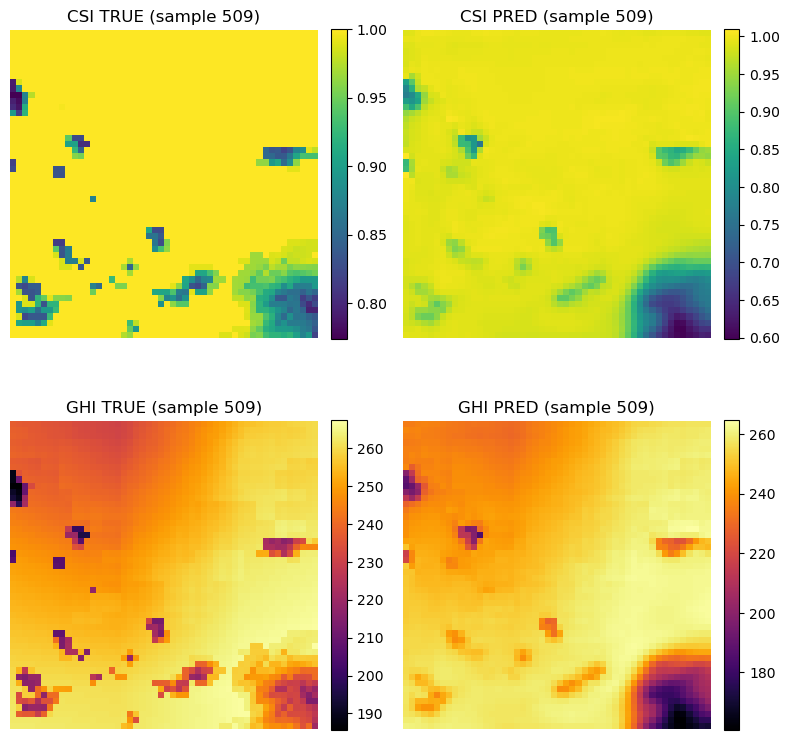

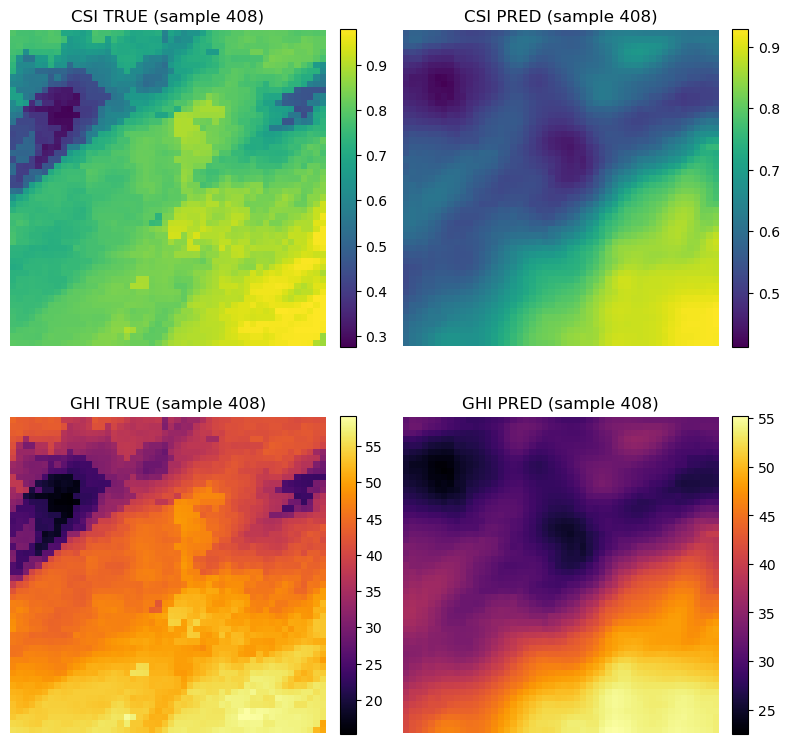

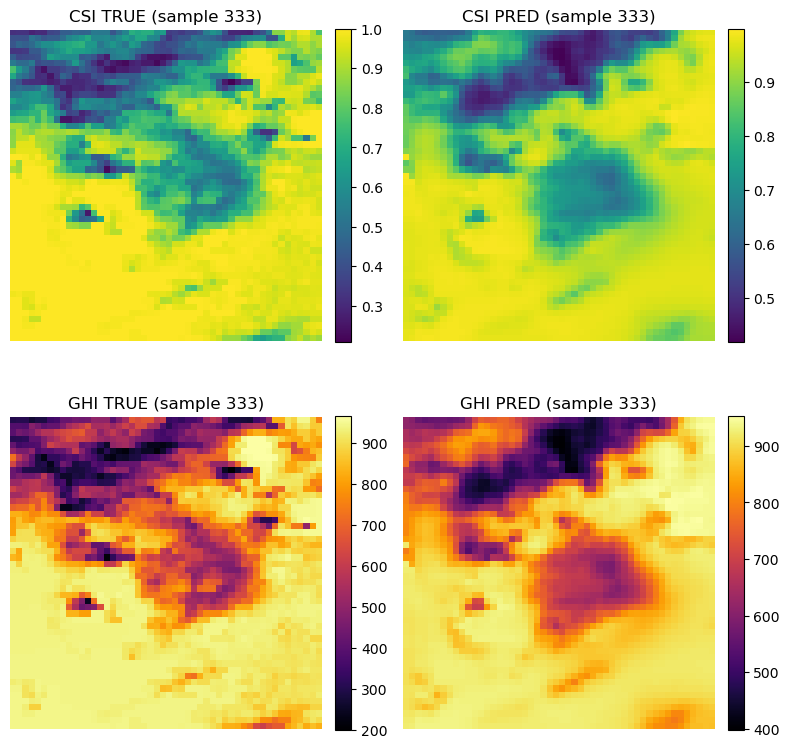

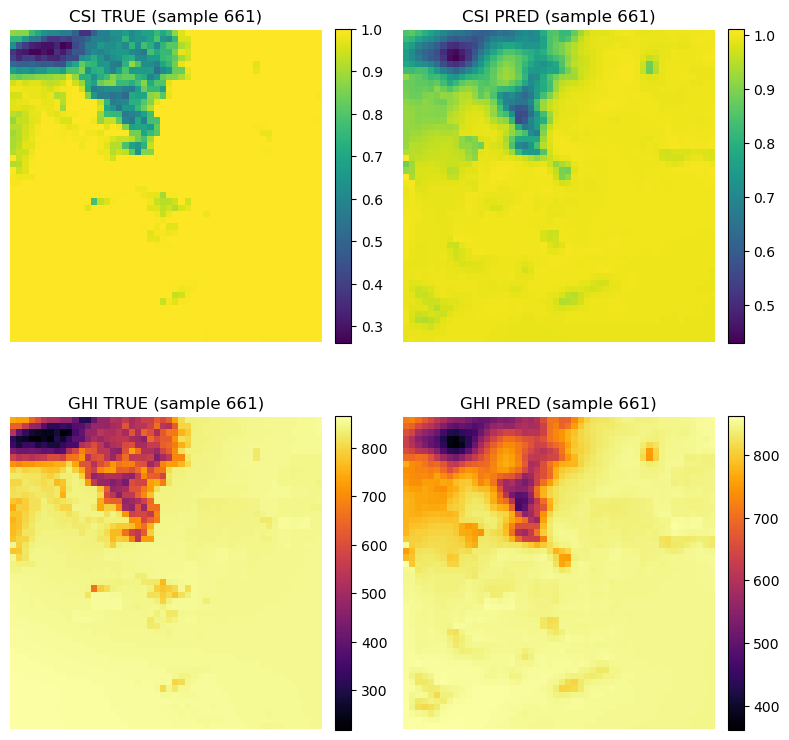

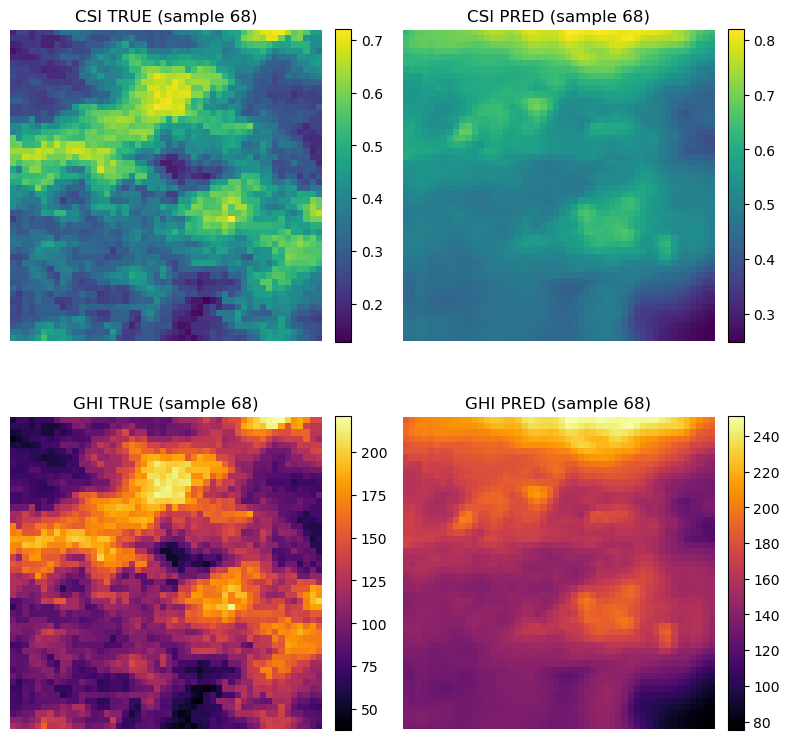

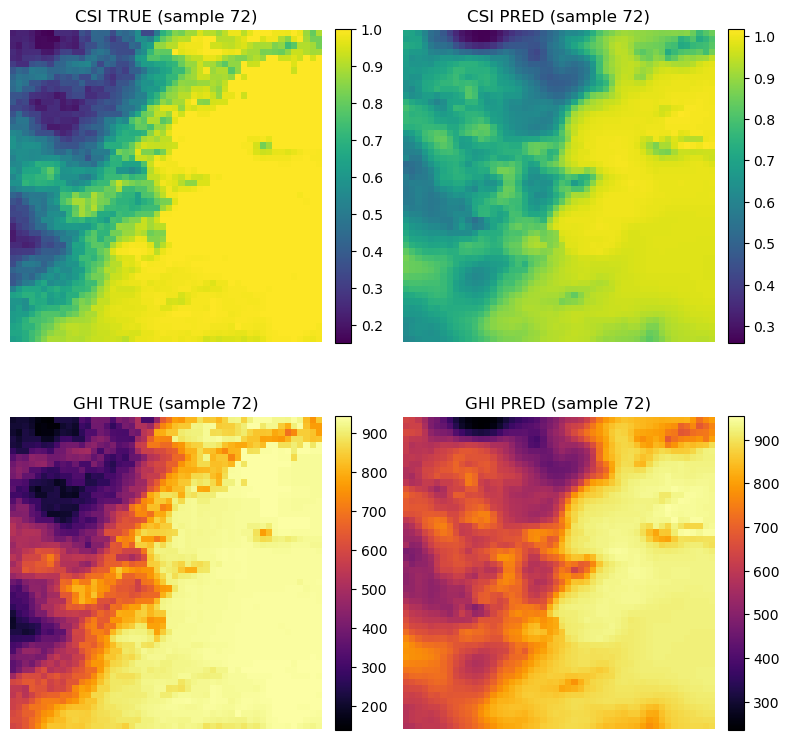

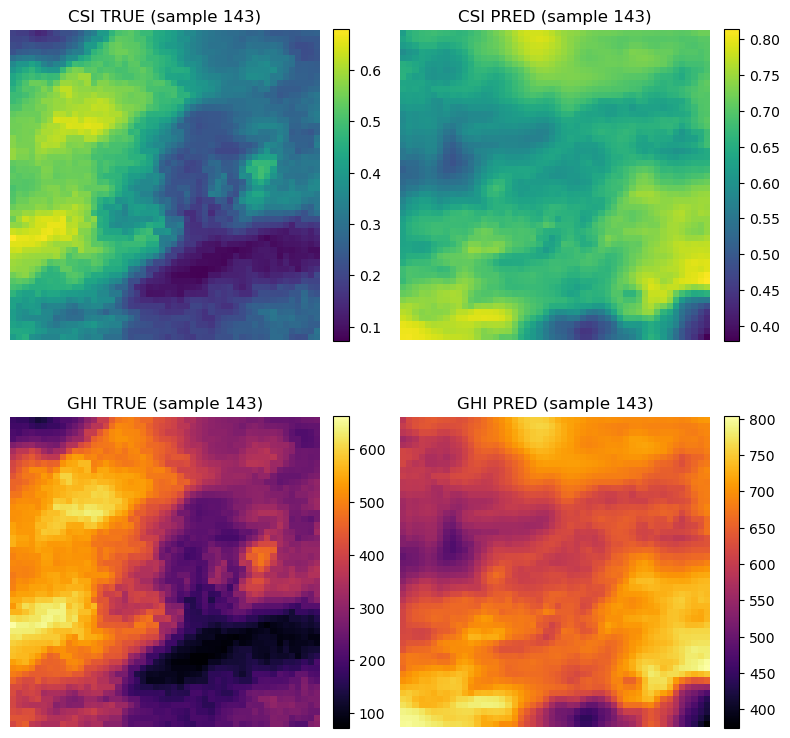

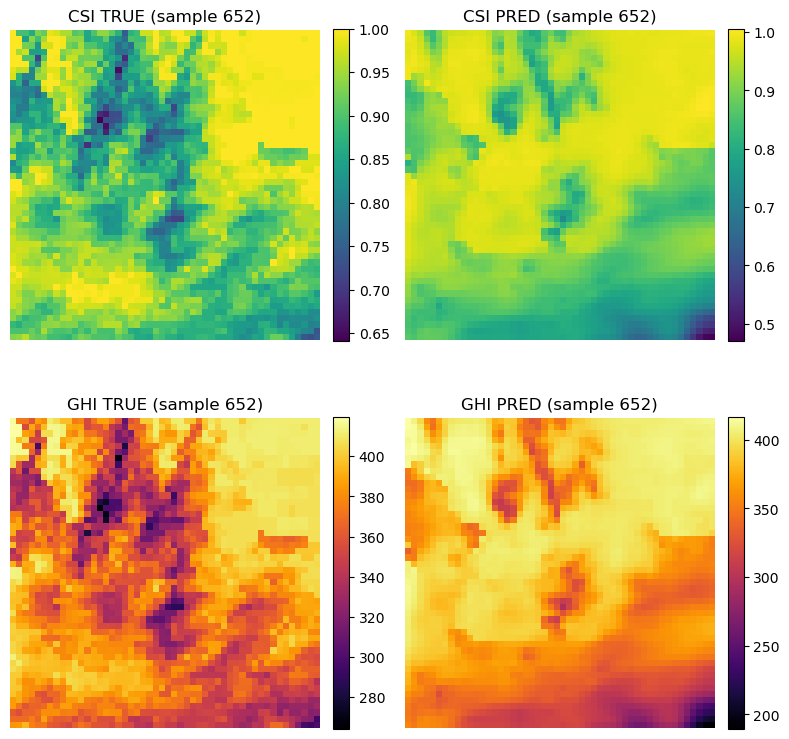

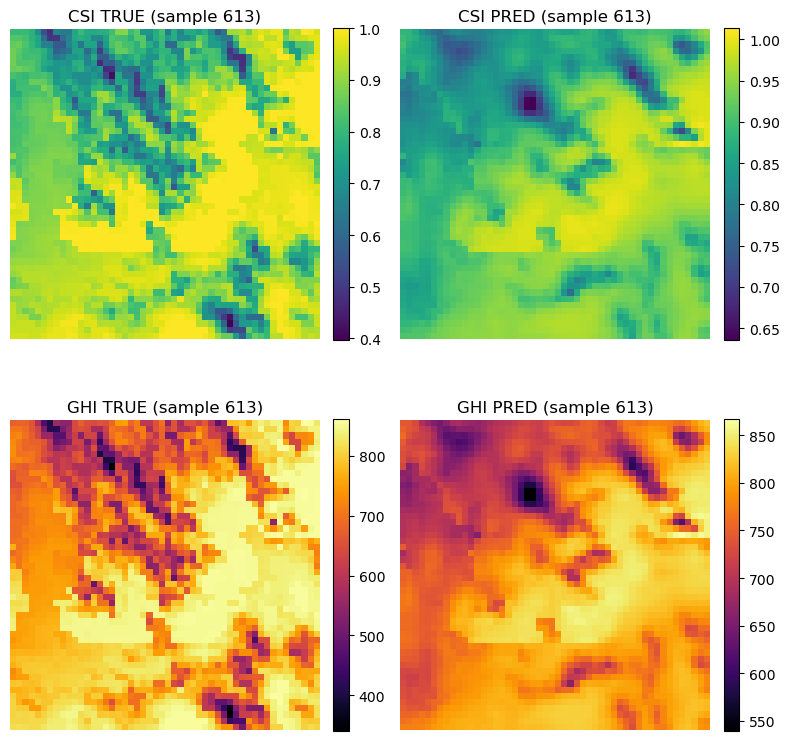

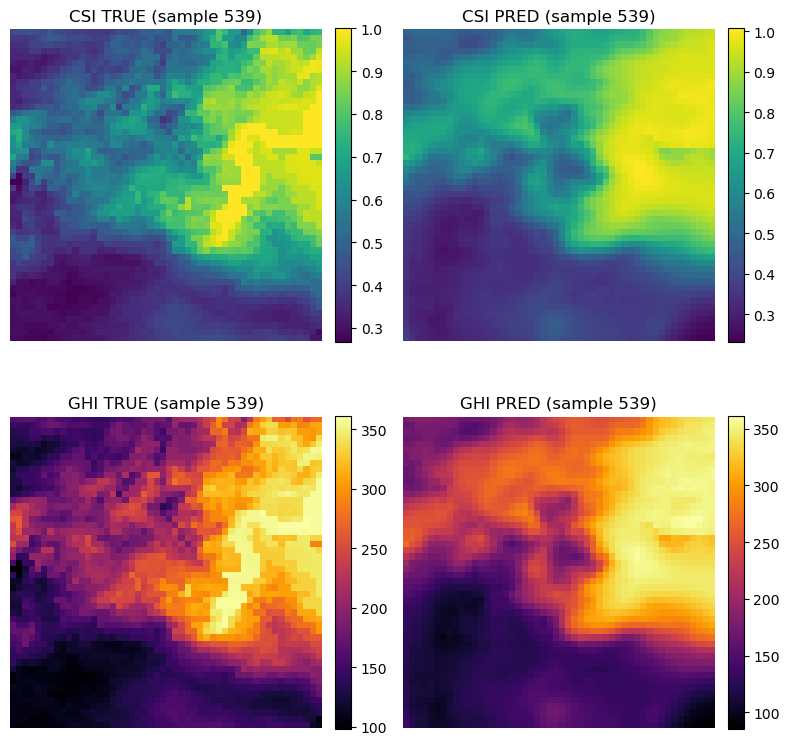

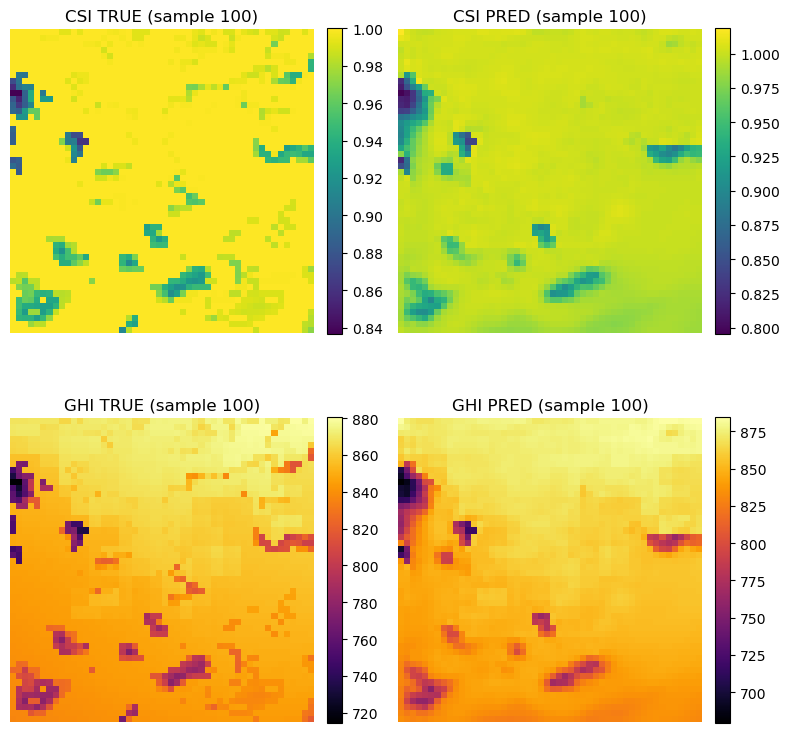

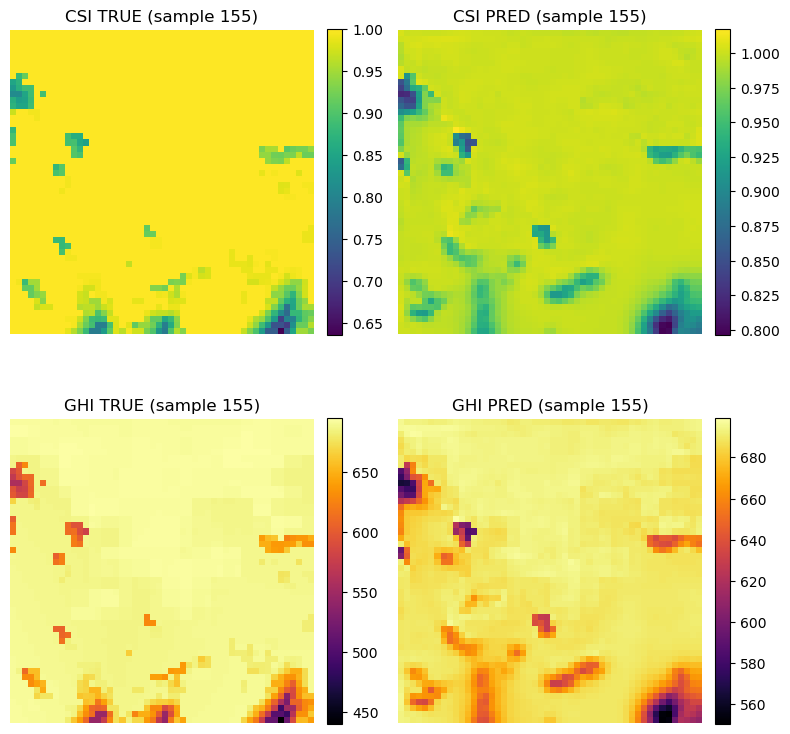

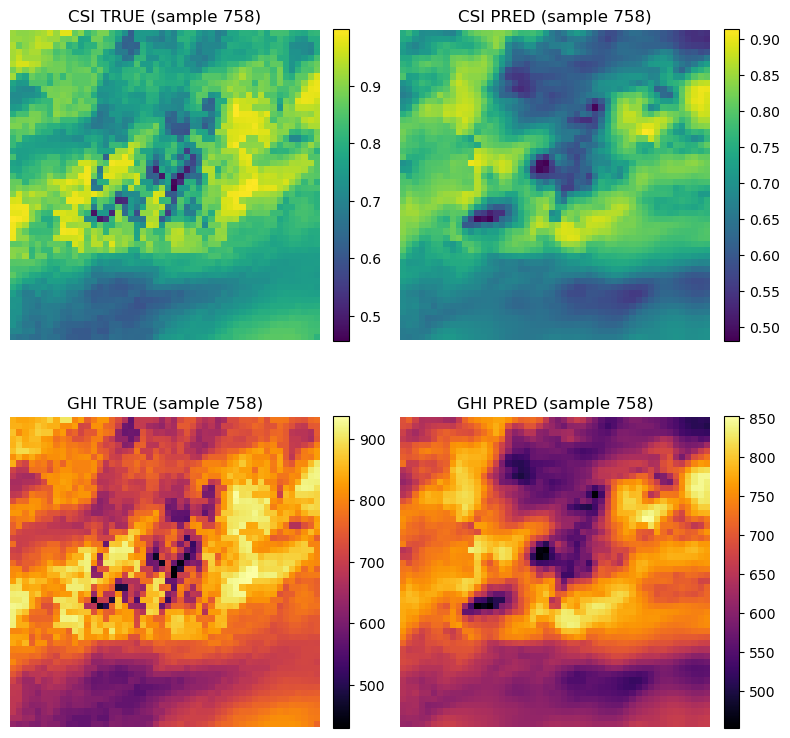

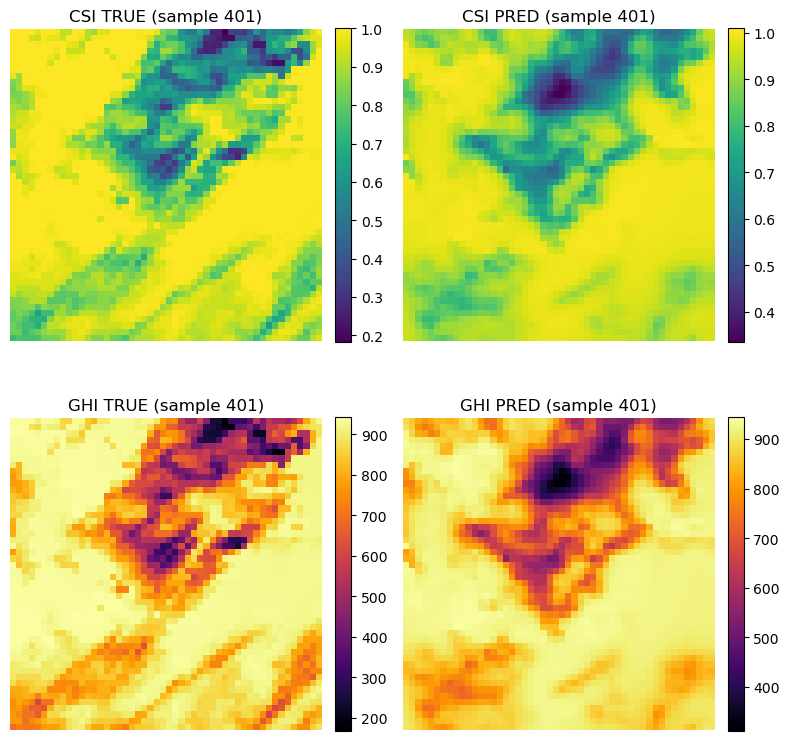

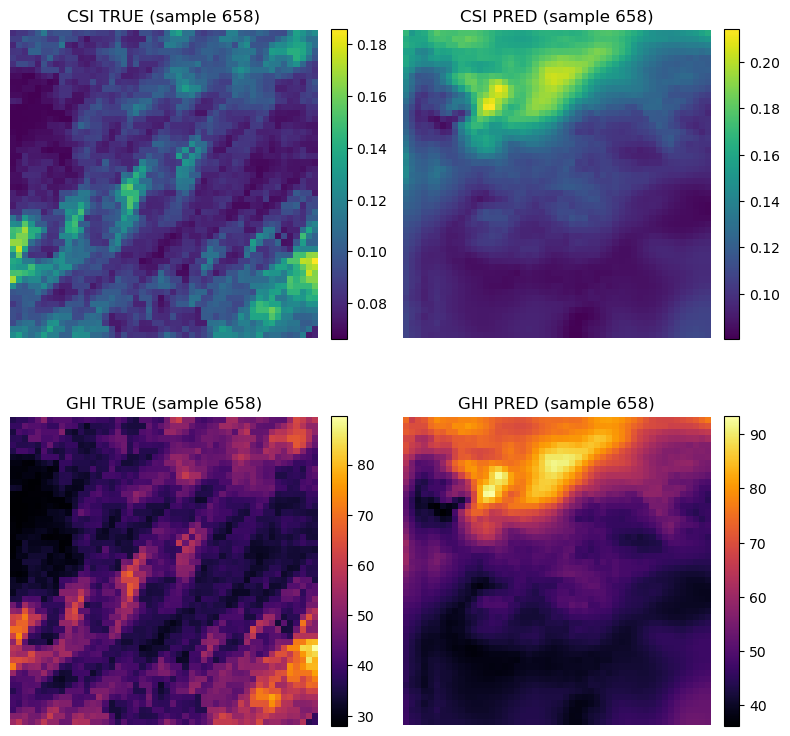

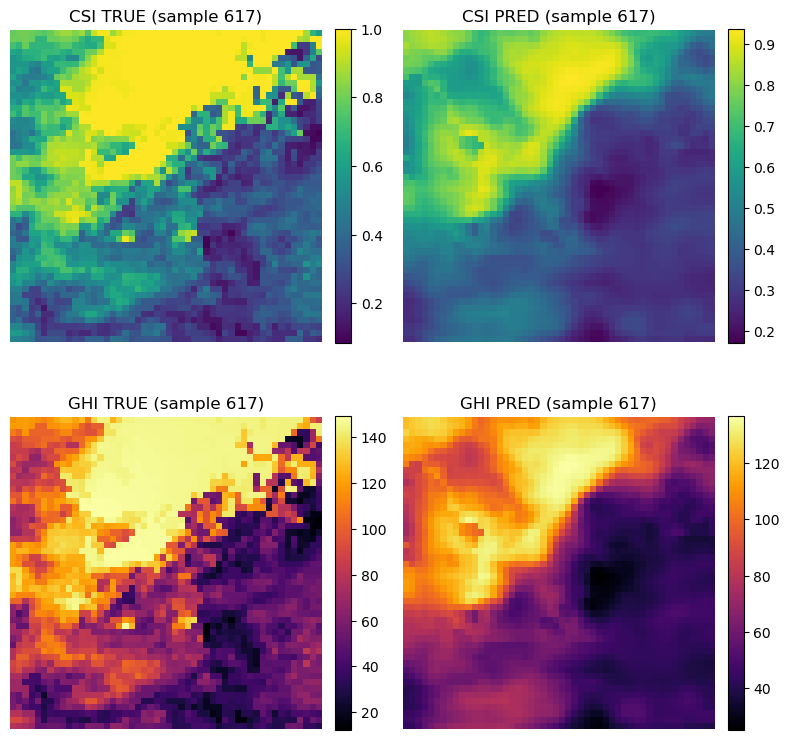

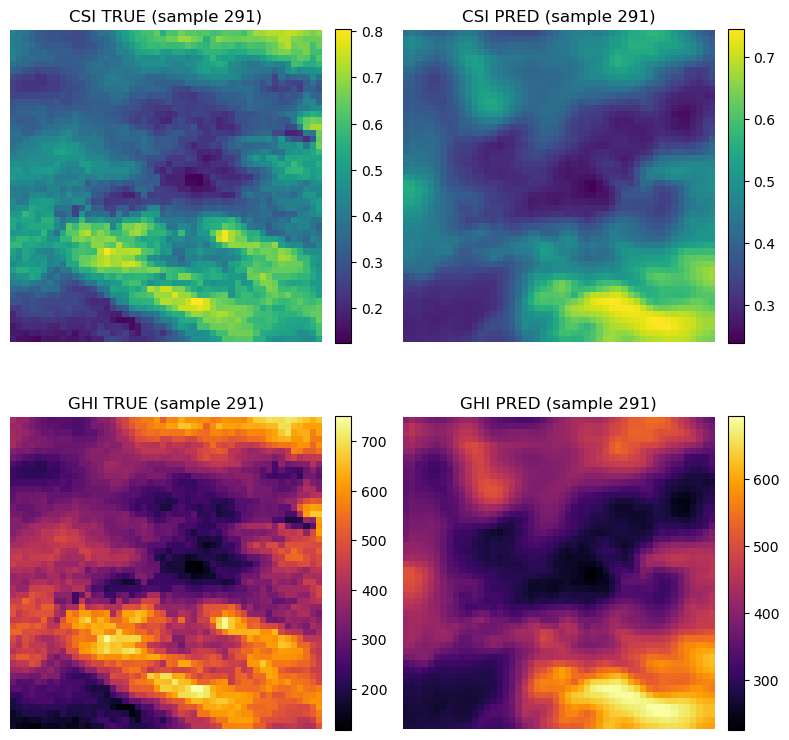

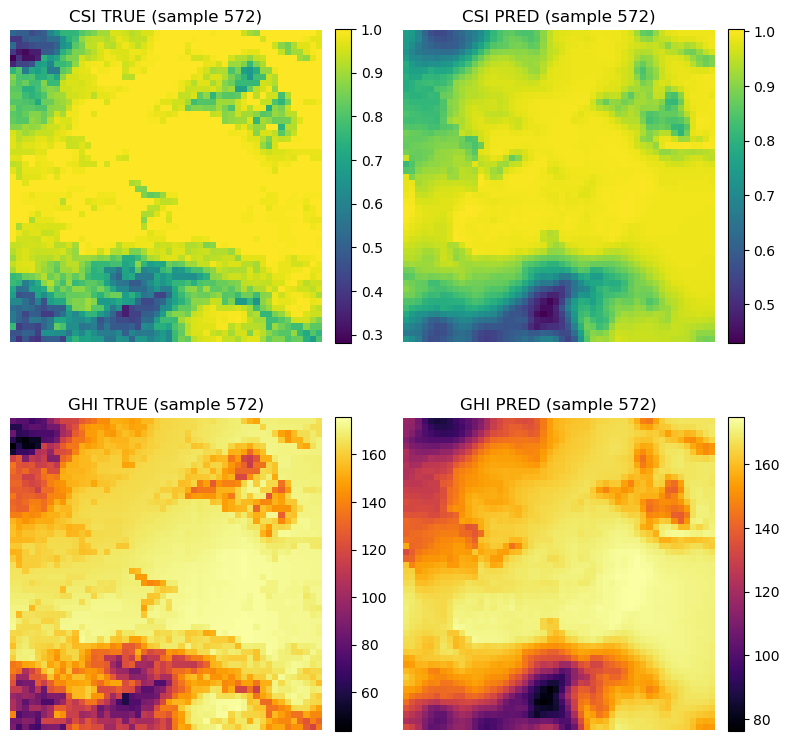

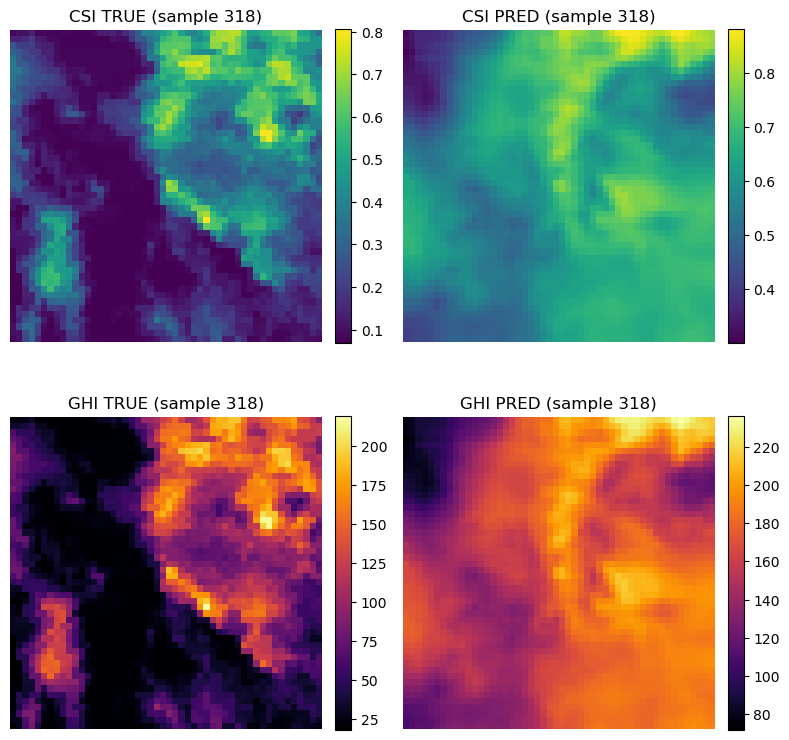

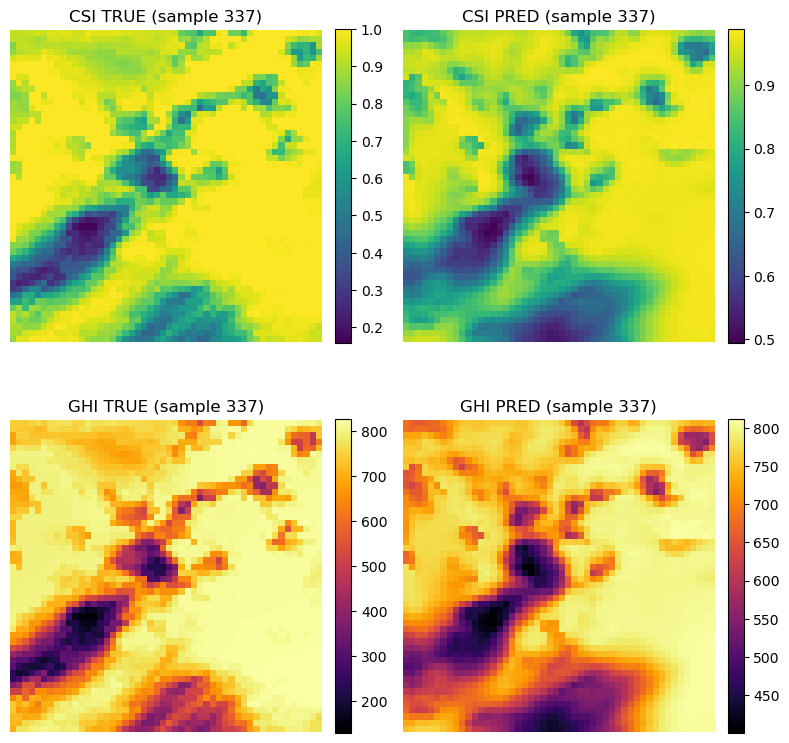

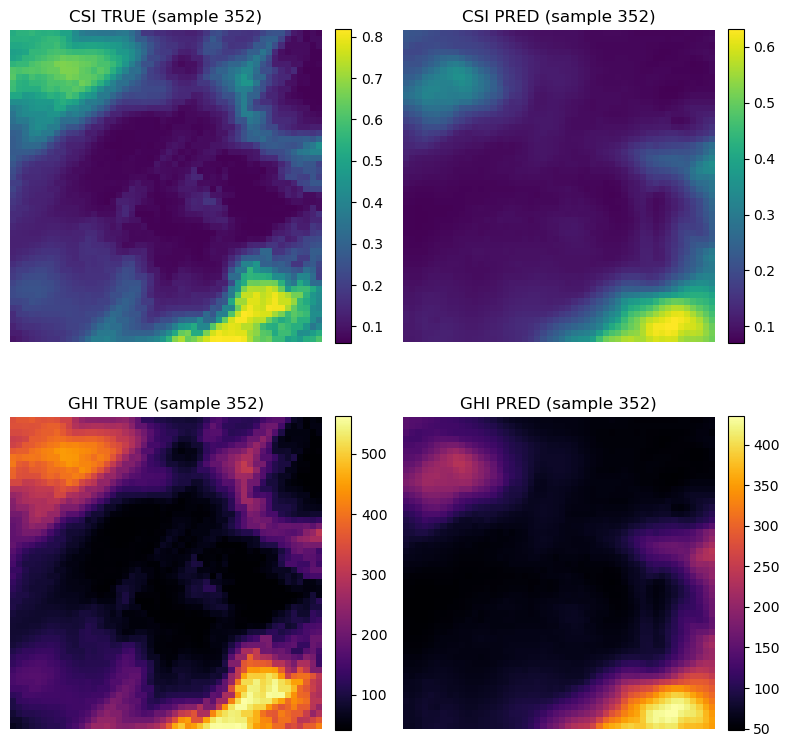

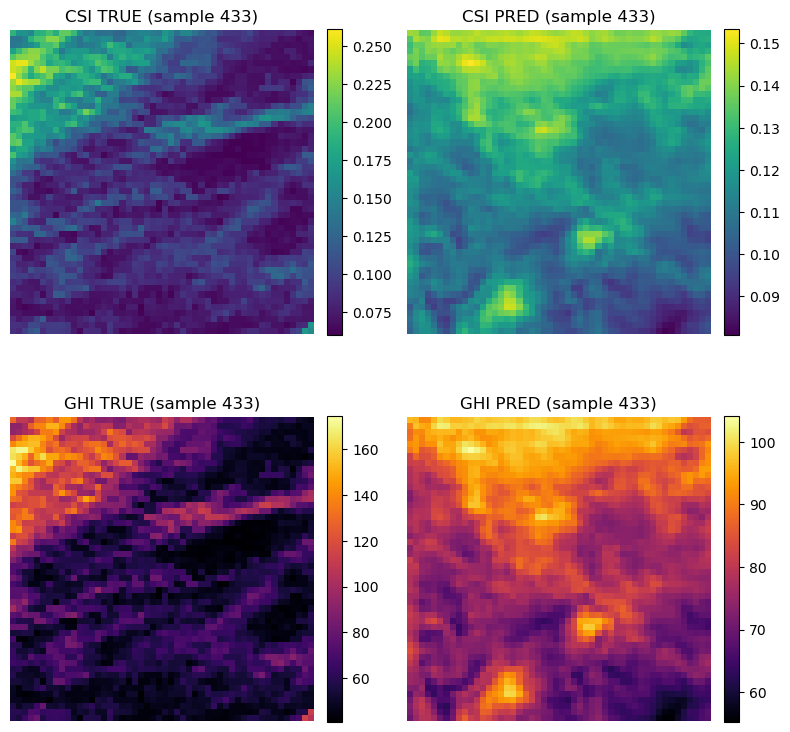

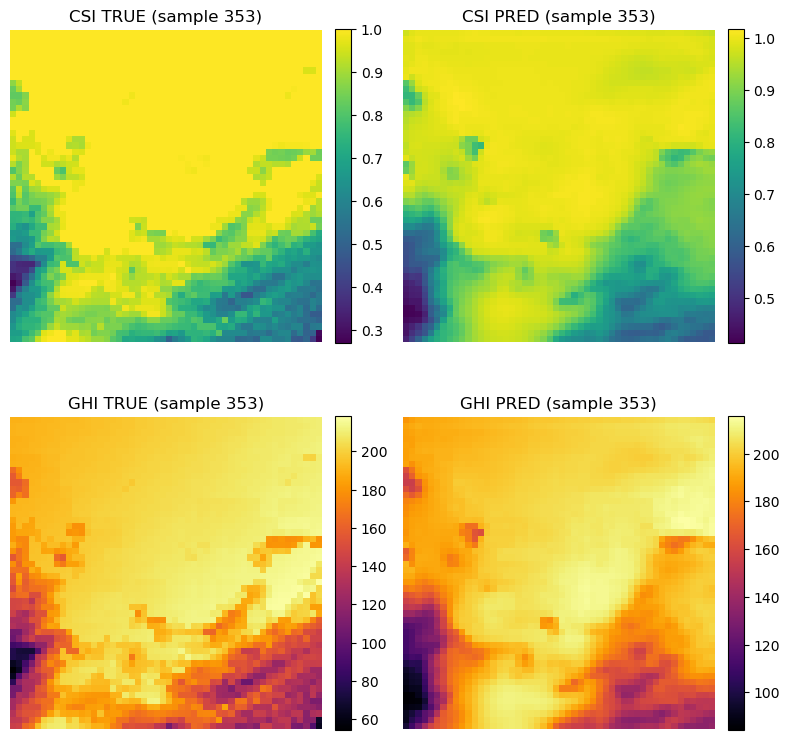

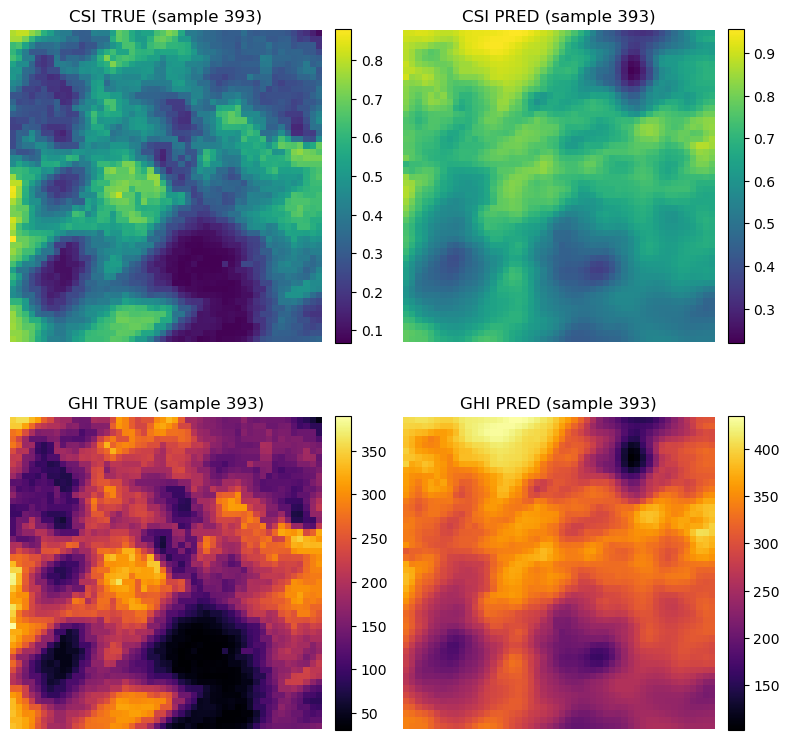

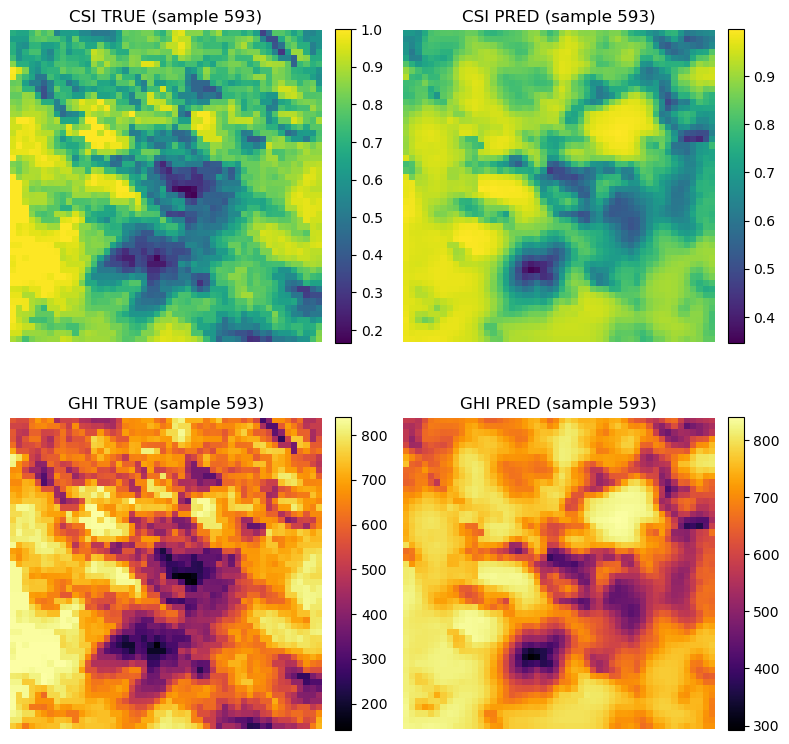

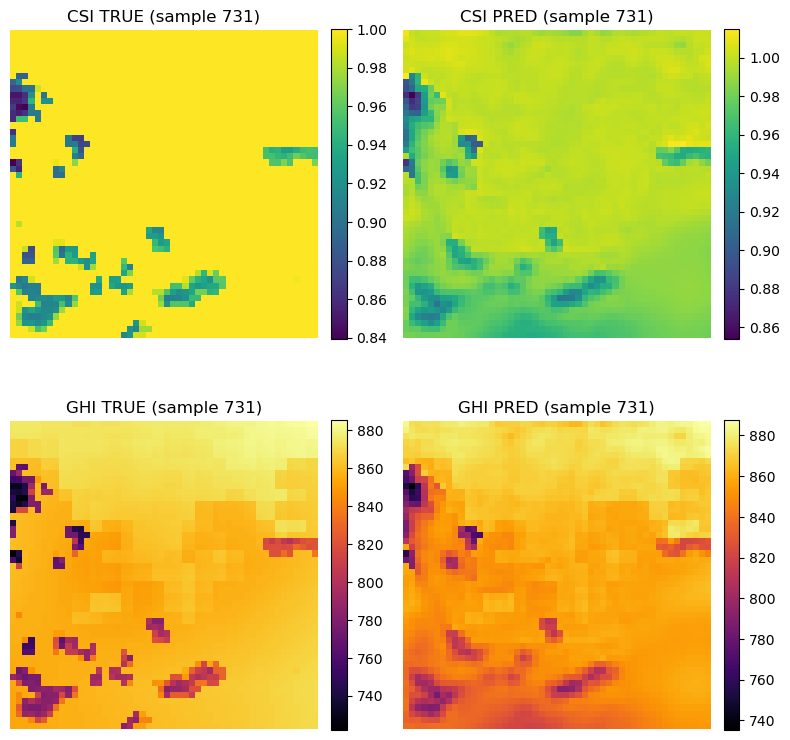

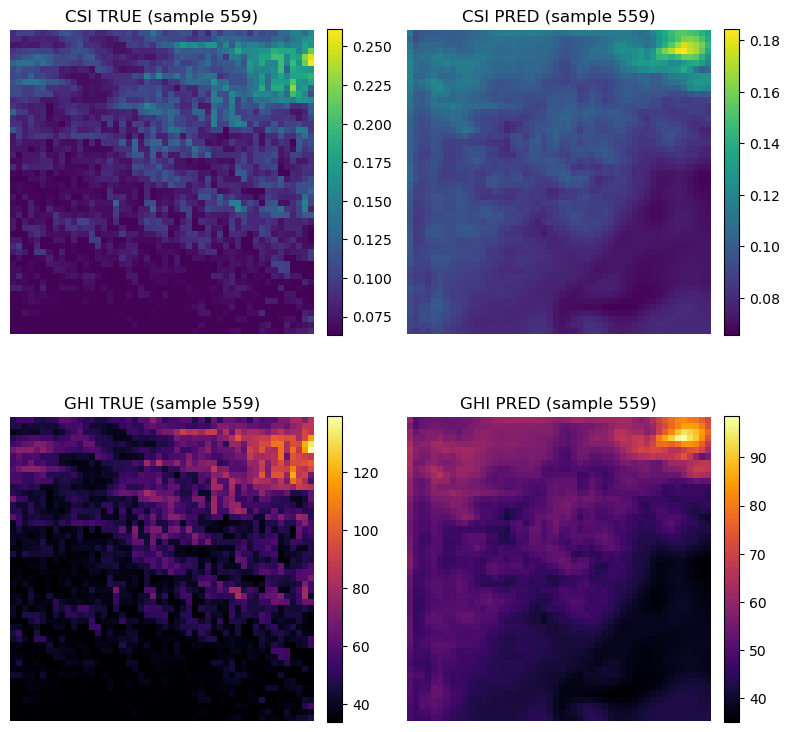

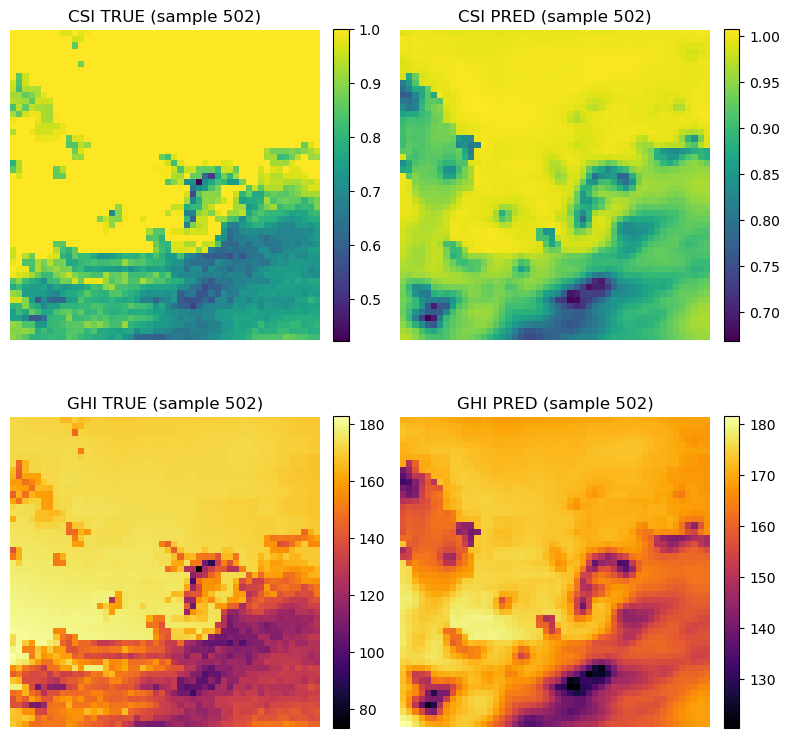

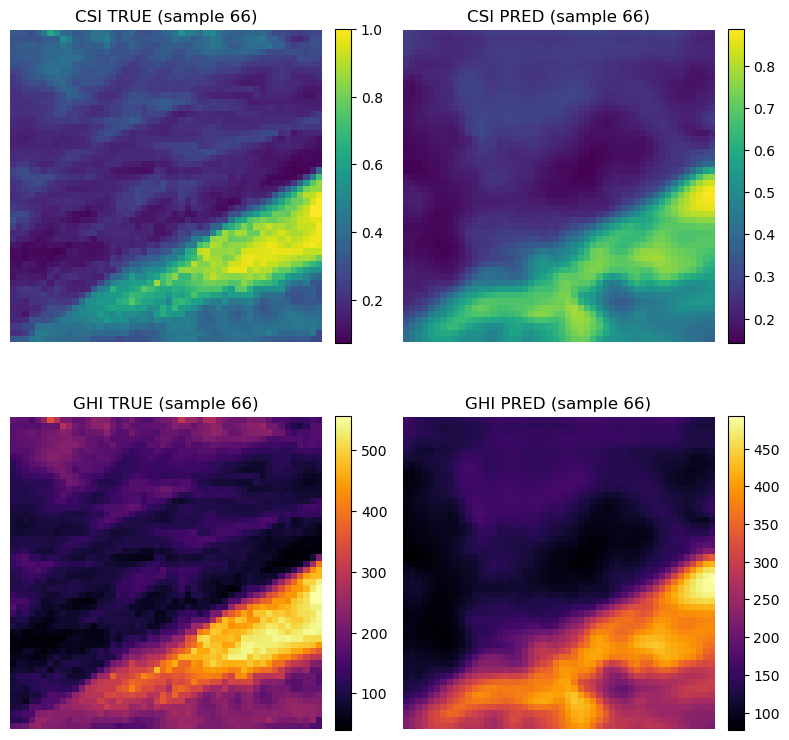

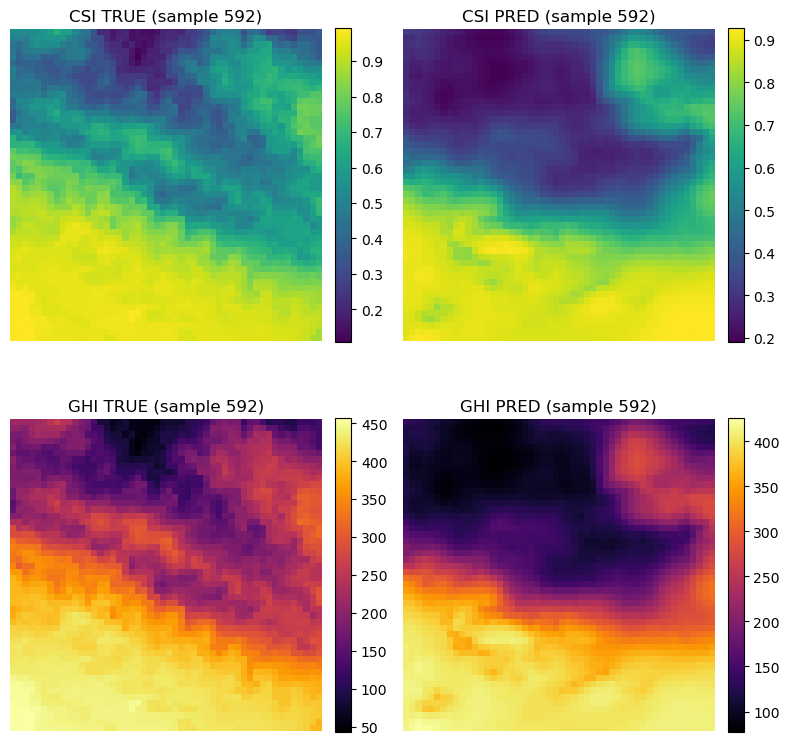

In [ ]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=20,
    seed=5
)